Research Question 8: How do the number and average timing of substitutions affect the number of shots on goal in the second half?

Retrieving the Data:

In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from scipy import stats
import json
import numpy as np

import soccerdata as sd 

data = sd.WhoScored(leagues="GER-Bundesliga", seasons="2024/2025", headless=True)

# Creating a list of all the game IDs of the Bundesliga season 2024/2025
game_ids = data.read_schedule()["game_id"].to_list()

events = data.read_events(match_id=game_ids)

substitutions = events[events["type"]=="SubstitutionOff"]
substitutions["minutes_played"] = (90 - substitutions["minute"]).clip(lower=0)

shot_types = ["Goal", "MissedShots", "SavedShot", "ShotOnPost"]
shots = events[(events["type"].isin(shot_types)) & (events["period"] == "SecondHalf")]

# Aggregate all the shots per match and team

shot_count = shots.groupby(["game_id", "team_id"]).size().reset_index(name="total_shots_secondHalf")

sub_count = substitutions.groupby(["game_id", "team_id"]).agg(
    sub_count=("type", "count"),
    avg_sub=("minute", "mean")
).reset_index()

shots = pd.merge(shots, sub_count[["game_id", "team_id", "avg_sub"]], on=["game_id", "team_id"], how="left")

shots["after_avgSub"] = shots["minute"] > shots["avg_sub"]

shot_distribution = shots.groupby(["game_id", "team_id", "after_avgSub"]).size().unstack(fill_value=0).reset_index()
shot_distribution.columns = ["game_id", "team_id", "shots_before_avgSub", "shots_after_avgSub"]

total_sub_time = substitutions.groupby(["game_id", "team_id"])["minutes_played"].sum().reset_index(name="total_sub_time")

df_RQ8 = pd.merge(sub_count, shot_count, on=["game_id", "team_id"], how="left").fillna(0)
df_RQ8 = pd.merge(df_RQ8, total_sub_time, on=["game_id", "team_id"], how="left").fillna(0)
df_RQ8 = pd.merge(df_RQ8, shot_distribution, on=["game_id", "team_id"], how="left").fillna(0)

df_RQ8["spm_before"] = df_RQ8["shots_before_avgSub"] / (df_RQ8["avg_sub"] - 45).clip(lower=1)
df_RQ8["spm_after"] = df_RQ8["shots_after_avgSub"] / (90 - df_RQ8["avg_sub"]).clip(lower=1)
df_RQ8["spm_diff"] = df_RQ8["spm_after"] - df_RQ8["spm_before"]

df_RQ8.to_json("RQ8.json", orient="records", indent=4)
df_RQ8.to_csv("RQ8.csv", index=False)




[03/16/26 19:52:21] INFO     No custom team name replacements found. You can configure these in       ]8;id=732060;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=162700;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py#92\92]8;;\
                             C:\Users\hinri\soccerdata\config\teamname_replacements.json.                          

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=626358;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=600564;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py#198\198]8;;\
                             C:\Users\hinri\soccerdata\config\league_dict.json.                                    

                    INFO     Saving cached data to C:\Users\hinri\soccerdata\data\WhoScored          ]8;id=136889;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=468285;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_common.py#249\249]8;;\

[03/16/26 19:52:29] INFO     Retrieving calendar for GER-Bundesliga 2425                           ]8;id=11639;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=412706;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#365\365]8;;\

                    INFO     [1/10] Retrieving fixtures for GER-Bundesliga 2425                    ]8;id=681427;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=796094;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#396\396]8;;\

...

                    INFO     [303/306] Retrieving game with id=1834451                             ]8;id=466974;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=789899;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

[03/16/26 19:52:53] INFO     [304/306] Retrieving game with id=1834459                             ]8;id=762999;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=642928;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [305/306] Retrieving game with id=1834447                             ]8;id=294349;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=810956;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [306/306] Retrieving game with id=1834463                             ]8;id=324524;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=135716;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

[03/16/26 19:53:03] WARNING  C:\Users\hinri\AppData\Local\Temp\ipykernel_17568\866398040.py:18:     warnings.py:110
                             SettingWithCopyWarning:                                                               
                             A value is trying to be set on a copy of a slice from a DataFrame.                    
                             Try using .loc = value instead                                                        
                                                                                                                   
                             See the caveats in the documentation:                                                 
                             https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#                
                             returning-a-view-versus-a-copy                                                        
                               substitutions["minutes_played"] = (90 -                                             
                             substitutions["minute"]).clip(lower=0)                                                
                                                                                                                   

Creating the visualization:

Shots on Goal in 2nd half by number of substitutions:

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=26554;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=797742;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py#223\223]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=974022;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=332533;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py#223\223]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

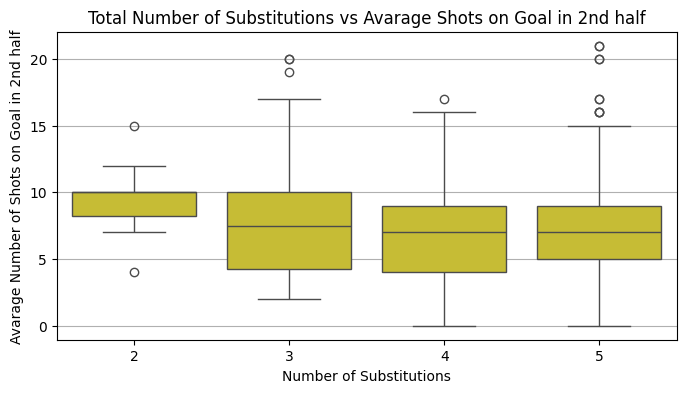

In [2]:
avg_shots = df_RQ8[df_RQ8["sub_count"].isin([2, 3, 4, 5])]

plt.figure(figsize=(8, 4))

sb.boxplot(x="sub_count", y="total_shots_secondHalf", data=avg_shots, color="#DED11D")

ax = plt.gca()
ax.set_axisbelow(True)

plt.grid(axis="y")

plt.title("Total Number of Substitutions vs Avarage Shots on Goal in 2nd half")
plt.xlabel("Number of Substitutions")
plt.ylabel("Avarage Number of Shots on Goal in 2nd half")

plt.savefig("SubCountBoxRQ8.png")

plt.show()

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=784331;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=987734;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py#223\223]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=237771;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=939257;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py#223\223]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

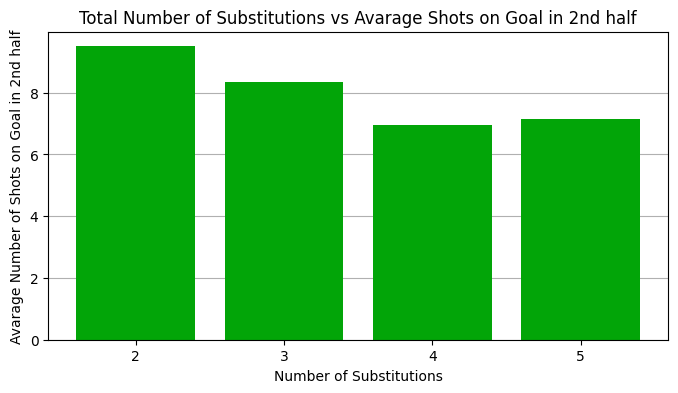

In [3]:
avg_shots = df_RQ8[df_RQ8["sub_count"].isin([2, 3, 4, 5])].groupby("sub_count")["total_shots_secondHalf"].mean()

plt.figure(figsize=(8, 4))

plt.bar(["2","3","4","5"],avg_shots.values, color="#02A508")

ax = plt.gca()
ax.set_axisbelow(True)

plt.grid(axis="y")

plt.title("Total Number of Substitutions vs Avarage Shots on Goal in 2nd half")
plt.xlabel("Number of Substitutions")
plt.ylabel("Avarage Number of Shots on Goal in 2nd half")

plt.savefig("SubCountBarRQ8.png")

plt.show()

Timing of the avarage substitution vs. change in shots per minute afterwards:

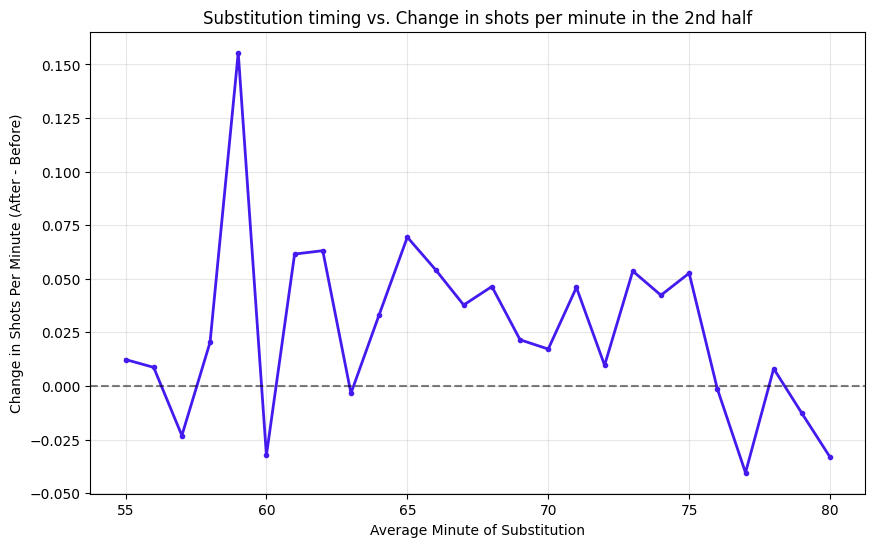

In [4]:
shot_diff_df = df_RQ8[(df_RQ8["avg_sub"] > 55) & (df_RQ8["avg_sub"] < 80)].copy()

aggregated_shotDiff_df = shot_diff_df.groupby(shot_diff_df["avg_sub"].round())["spm_diff"].mean()

plt.figure(figsize=(10, 6))
plt.plot(aggregated_shotDiff_df.index, aggregated_shotDiff_df.values, color="#441AEE", marker=".", linewidth=2)

plt.axhline(0, color="black", linestyle="--", alpha=0.5)

plt.title("Substitution timing vs. Change in shots per minute in the 2nd half")
plt.xlabel("Average Minute of Substitution")
plt.ylabel("Change in Shots Per Minute (After - Before)")
plt.grid(True, alpha=0.3)

plt.savefig("MeanSubRQ8.png")

plt.show()

Total Number of shots in the second half vs. number of minutes played by substituted players

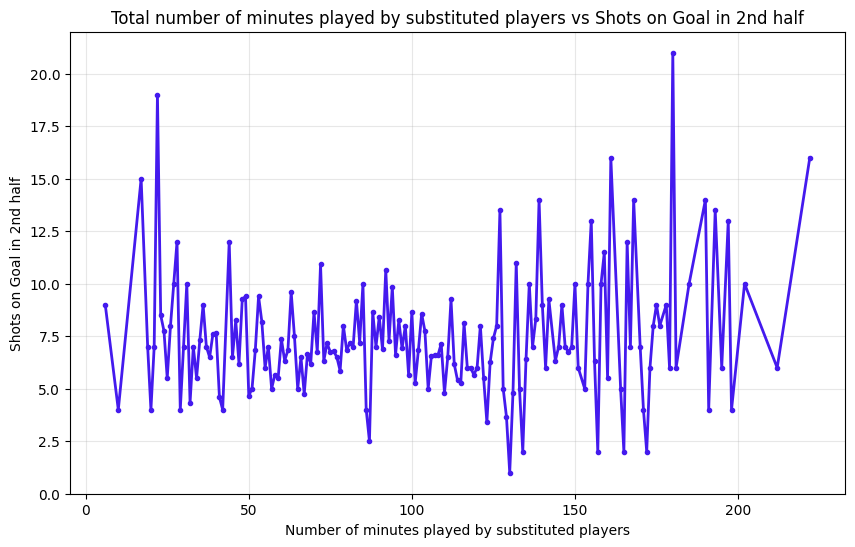

In [5]:
aggregated_subMin_df = df_RQ8.groupby(df_RQ8["total_sub_time"].round())["total_shots_secondHalf"].mean()

plt.figure(figsize=(10, 6))
plt.plot(aggregated_subMin_df.index, aggregated_subMin_df.values, color="#441AEE", marker=".", linewidth=2)

plt.title("Total number of minutes played by substituted players vs Shots on Goal in 2nd half")
plt.xlabel("Number of minutes played by substituted players")
plt.ylabel("Shots on Goal in 2nd half")
plt.grid(True, alpha=0.3)

plt.savefig("TotalTimeRQ8.png")

plt.show()

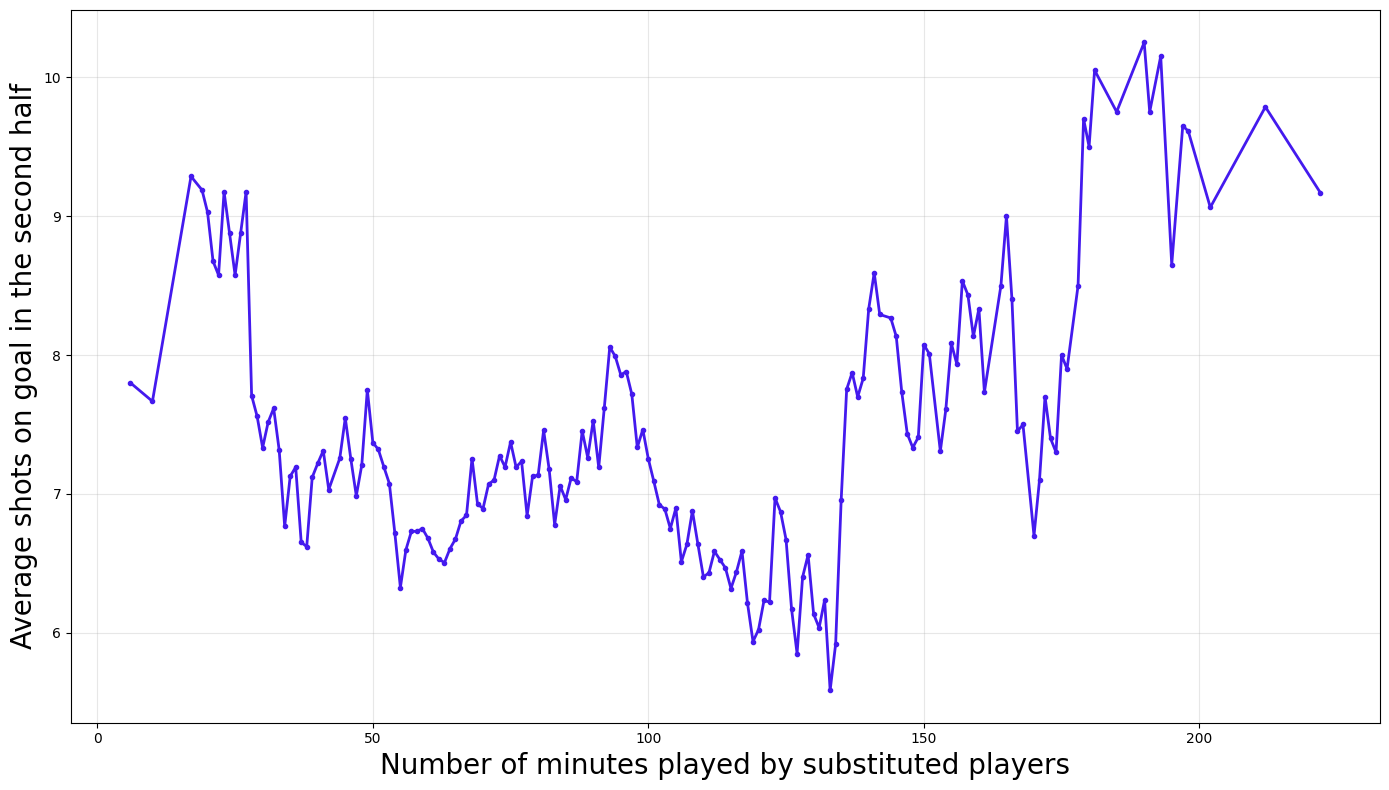

In [17]:
smoothed_data = aggregated_subMin_df.rolling(window=10, center=True, min_periods=2).mean()

plt.figure(figsize=(14, 8))
plt.plot(smoothed_data.index, smoothed_data.values, color="#441AEE", marker=".", linewidth=2)

plt.xlabel("Number of minutes played by substituted players", fontsize=20)
plt.ylabel("Average shots on goal in the second half", fontsize=20)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("TotalTimeSmoothedRQ8.png")

plt.show()